## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Robinhood User Churn Analysis</p>

<a id="toc"></a>

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Content</p>

* [INTRODUCTION](#0)
* [IMPORTING MODULES, LOADING DATA & DATA REVIEW](#1)
* [PREPROCESSING](#2)
* [EXPLORATORY DATA ANALYSIS (EDA)](#3)    
* [SCALING, CATEGORICAL VARIABLES, SPLITTING](#4)
* [MODELS](#5)
* [CONCLUSION](#6)

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Introduction</p>

<a id="0"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true"
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 1.1 Information About the Project

**Objective:**  
The primary objective of this project is to build a classification model to understand why and which users withdraw their funds and churn from the Robinhood platform. Solving this problem is critical for the growth team to improve user retention and lower overall churn rates. For this task, a user is explicitly defined as churned when their equity value (the amount of money in their Robinhood account) falls below $10 for a period of 28 consecutive calendar days or longer after having previously been at least $10.

**Scope:**  
The scope of this project includes exploring the datasets to calculate the historical churn percentage, engineering the target variable based on the 28-day equity rule, and developing a classifier that assigns a churn probability to each user. The model's performance will be rigorously evaluated using ROC-AUC to account for classification thresholds and potential class imbalance. Finally, the project will identify and list the most important features that correlate to user churn to provide actionable insights.

## 1.2 Description of the Dataset

- **Source:** The dataset is provided directly by Robinhood and represents internal user behavior and account equity tracking.
- **Size:** The number of records and columns.
- **Type:** Explain if it’s time series, tabular, text, or image data.

## 1.3 Description of the Columns
Provide an in-depth explanation of each feature in the dataset. Identify:

- **Target Variable:** What are you predicting (e.g., a binary or multiclass label, a continuous value)?
- **Feature Variables:** A brief description of the important columns, including their data types.

---



## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Modules, Load Data & Data Review</p>

<a id="1"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

In [165]:
# Standard Library
import random
import warnings
import shap

# Third-Party Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output, display
from scipy.stats import randint, uniform

# Scikit-learn
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# Gradient Boosting Libraries
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [70]:
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### Helper Functions

In [71]:
def print_cc(df, columns):
    """
    Takes a DataFrame and a list of columns, then prints a clean, 
    formatted list of unique values ordered by highest count first.
    """
    print(f"Total Rows: {len(df)}\n")

    for col in columns:
        val_counts = df[col].value_counts()
        
        items = [f"{count} '{val}'" for val, count in val_counts.items()]
        
        clean_string = ", ".join(items)
        
        print(f"'{col}': {len(items)} [{clean_string}],")

In [72]:
def log_and_update_results(model_name, fitted_pipeline, X_train, y_train, X_test, y_test, results, params=None):
    """
    Evaluates a fitted pipeline on both train and test sets, appends metrics along with a single column 
    containing a dictionary of hyperparameters to a results list, and returns an updated, sorted DataFrame.
    """
    # Calculate the number of features in the training set
    num_features = X_train.shape[1]

    # Evaluate the pipeline on the training set
    y_train_pred_proba = fitted_pipeline.predict_proba(X_train)[:, 1]
    train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
    
    # Evaluate the pipeline on the test set
    y_test_pred_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

    # Auto increment run_id
    existing_runs = sum(1 for row in results if row['model'] == model_name)
    next_run_id = existing_runs + 1
    
    # If params are provided, remove 'model__' prefixes
    clean_params = {}
    if params:
        clean_params = {k.split('__')[-1]: v for k, v in params.items()}
    else:
        # For baseline models
        model_step = fitted_pipeline.named_steps['model']
        clean_params = model_step.get_params()
    
    # Append results
    results.append({
        'model': model_name,
        'run_id': next_run_id,
        'features': num_features,
        'train_roc_auc': train_roc_auc,
        'test_roc_auc': test_roc_auc,
        'hyperparameters': clean_params
    })
    
    # Return updated results sorted by test ROC AUC
    results_df = (
        pd.DataFrame(results)
        .sort_values(by='test_roc_auc', ascending=False)
        .reset_index(drop=True) 
    )

    # Save to CSV
    results_df.to_csv('model_results.csv', index=False)

    return results_df

In [73]:
def tune_hyperparameters(pipeline, param_grid, X_train, y_train, fit_params=None, n_iter=50, cv=10, scoring='roc_auc', seed=42):
    """
    Initializes and runs a RandomizedSearchCV on the provided pipeline and data.
    
    Args:
        pipeline: The sklearn Pipeline or estimator to tune.
        param_grid (dict): The dictionary of parameter distributions.
        X_train (array-like): Training features.
        y_train (array-like): Training labels.
        fit_params (dict, optional): Additional parameters to pass to the fit method (e.g., sample weights).
        n_iter (int): Number of parameter settings that are sampled.
        cv (int): Number of cross-validation folds.
        scoring (str): Scoring metric to optimize.
        seed (int): Random state for reproducibility.
        
    Returns:
        Fitted RandomizedSearchCV object.
    """
    if fit_params is None:
        fit_params = {}
        
    clf = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        random_state=seed,
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the search object
    clf.fit(X_train, y_train, **fit_params)
    
    return clf

In [74]:
def print_bh(best_params):
    """
    Cleans and prints the best hyperparameters found during tuning.
    
    Args:
        best_params (dict): A dictionary of the best parameters (e.g., from clf.best_params_).
    """
    print("\n=== Best Hyperparameters Found ===")
    for param, value in best_params.items():
        clean_name = param.split('__')[-1]
        
        # Format floats for cleaner output
        if isinstance(value, float):
            print(f" - {clean_name}: {value:.4f}")
        else:
            print(f" - {clean_name}: {value}")
            
    print("==================================\n")

### Features Data

In [75]:
features_df_org = pd.read_csv("data/features_data.csv")
features_df = features_df_org.copy()

features_df.head(3).T

,0,1,2
risk_tolerance,high_risk_tolerance,med_risk_tolerance,med_risk_tolerance
investment_experience,limited_investment_exp,limited_investment_exp,limited_investment_exp
liquidity_needs,very_important_liq_need,very_important_liq_need,very_important_liq_need
platform,Android,Android,iOS
time_spent,33.129417,16.573517,10.008367
instrument_type_first_traded,stock,stock,stock
first_deposit_amount,40.0,200.0,25.0
time_horizon,med_time_horizon,short_time_horizon,long_time_horizon
user_id,895044c23edc821881e87da749c01034,458b1d95441ced242949deefe8e4b638,c7936f653d293479e034865db9bb932f


In [76]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5584 entries, 0 to 5583
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   risk_tolerance                5584 non-null   str    
 1   investment_experience         5584 non-null   str    
 2   liquidity_needs               5584 non-null   str    
 3   platform                      5584 non-null   str    
 4   time_spent                    5584 non-null   float64
 5   instrument_type_first_traded  5584 non-null   str    
 6   first_deposit_amount          5584 non-null   float64
 7   time_horizon                  5584 non-null   str    
 8   user_id                       5584 non-null   str    
dtypes: float64(2), str(7)
memory usage: 392.8 KB


In [77]:
features_df.nunique()

risk_tolerance                     3
investment_experience              4
liquidity_needs                    3
platform                           3
time_spent                      4502
instrument_type_first_traded      11
first_deposit_amount             317
time_horizon                       3
user_id                         5584
dtype: int64

In [78]:
features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent,5584.0,34.509706,155.080551,0.0,2.848908,13.474708,33.823829,8788.32945
first_deposit_amount,5584.0,633.566805,2118.323263,0.0,50.000000,100.000000,500.000000,50000.00000


In [79]:
cat_cols = features_df.select_dtypes(include="str").columns.tolist()
cat_cols.remove("user_id")

num_cols = features_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print_cc(features_df, cat_cols)

Total Rows: 5584

'risk_tolerance': 3 [3566 'high_risk_tolerance', 1779 'med_risk_tolerance', 239 'low_risk_tolerance'],
'investment_experience': 4 [2578 'limited_investment_exp', 1796 'no_investment_exp', 1134 'good_investment_exp', 76 'extensive_investment_exp'],
'liquidity_needs': 3 [4217 'very_important_liq_need', 1109 'somewhat_important_liq_need', 258 'not_important_liq_need'],
'platform': 3 [3550 'iOS', 1529 'Android', 505 'both'],
'instrument_type_first_traded': 11 [4827 'stock', 383 'etp', 197 'adr', 55 'mlp', 55 'reit', 20 'cef', 16 'wrt', 13 '0', 9 'rlt', 8 'lp', 1 'tracking'],
'time_horizon': 3 [2833 'short_time_horizon', 1833 'long_time_horizon', 918 'med_time_horizon'],


In [80]:
features_df.isnull().sum()

risk_tolerance                  0
investment_experience           0
liquidity_needs                 0
platform                        0
time_spent                      0
instrument_type_first_traded    0
first_deposit_amount            0
time_horizon                    0
user_id                         0
dtype: int64

In [81]:
features_df.duplicated().sum()

np.int64(0)

Investigate:

* Zeros for time spent
* Zeros for first deposit amount
* Zeros in instrument type first traded
* Robinhood does not support limited partnerships (lp), tracking stocks, or non-tradeable corporate actions like rights (rlt) (https://robinhood.com/us/en/support/articles/investments-you-can-make-on-robinhood/)

Possible Contradictions:

* Clueless Trader: Cases where a new investor with no investment exp trading 'wrt' (Warrants) or 'mlp' (Master limited partnerships)

* A user with low risk tolerance trading outside ETPs (Exchange Traded Products), cef (Closed-end Funds), or stocks

* Very important liquidity needs with long time horizon

* Short time horizon that is not also high risk tolerance

### Equity Value Data

In [82]:
equity_df_org = pd.read_csv("data/equity_value_data.csv")
equity_df = equity_df_org.copy()

equity_df.head(3).T

,0,1,2
timestamp,2016-11-16T00:00:00Z,2016-11-17T00:00:00Z,2016-11-18T00:00:00Z
close_equity,48.16,48.16,48.16
user_id,bcef4fa9b0bdf22bcf7deae708decf03,bcef4fa9b0bdf22bcf7deae708decf03,bcef4fa9b0bdf22bcf7deae708decf03


In [83]:
equity_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1119158 entries, 0 to 1119157
Data columns (total 3 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   timestamp     1119158 non-null  str    
 1   close_equity  1119158 non-null  float64
 2   user_id       1119158 non-null  str    
dtypes: float64(1), str(2)
memory usage: 25.6 MB


In [84]:
equity_df.nunique()

timestamp          255
close_equity    531483
user_id           5584
dtype: int64

In [85]:
equity_df.describe().T

,count,mean,std,min,25%,50%,75%,max
close_equity,1119158.0,3976.953266,13085.903764,10.0,111.54,578.74,2564.56,478948.41


In [86]:
equity_df.isnull().sum()

timestamp       0
close_equity    0
user_id         0
dtype: int64

In [87]:
equity_df.duplicated().sum()

np.int64(0)

Investigate:

* Timestamp format

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Preprocessing</p>

<a id="2"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 2.1 Data Cleaning



### Timestamp

In [88]:
equity_df['timestamp'].value_counts(dropna=False)

timestamp
2017-03-09T00:00:00Z    5274
2017-03-10T00:00:00Z    5269
2017-03-13T00:00:00Z    5263
2017-03-08T00:00:00Z    5257
2017-03-14T00:00:00Z    5257
                        ... 
2016-08-19T00:00:00Z    3034
2016-08-18T00:00:00Z    2319
2017-08-18T00:00:00Z    2226
2016-08-17T00:00:00Z     911
2016-08-16T00:00:00Z      64
Name: count, Length: 255, dtype: int64

In [89]:
equity_df['timestamp'] = pd.to_datetime(equity_df['timestamp'])

equity_df['timestamp'].value_counts(dropna=False)

timestamp
2017-03-09 00:00:00+00:00    5274
2017-03-10 00:00:00+00:00    5269
2017-03-13 00:00:00+00:00    5263
2017-03-08 00:00:00+00:00    5257
2017-03-14 00:00:00+00:00    5257
                             ... 
2016-08-19 00:00:00+00:00    3034
2016-08-18 00:00:00+00:00    2319
2017-08-18 00:00:00+00:00    2226
2016-08-17 00:00:00+00:00     911
2016-08-16 00:00:00+00:00      64
Name: count, Length: 255, dtype: int64

### Time Spent

In [90]:
features_df['time_spent'].value_counts(dropna=False)

time_spent
0.000000     1079
93.746633       2
10.226667       2
2.012450        2
3.755967        2
             ... 
8.339283        1
7.241383        1
22.967167       1
10.338417       1
18.470950       1
Name: count, Length: 4502, dtype: int64

In [91]:
tp_zs = features_df.query("time_spent == 0")

tp_zs.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent,1079.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
first_deposit_amount,1079.0,762.904995,2123.994099,1.0,75.0,200.0,500.0,35000.0


In [92]:
print_cc(tp_zs, cat_cols)

Total Rows: 1079

'risk_tolerance': 3 [767 'high_risk_tolerance', 263 'med_risk_tolerance', 49 'low_risk_tolerance'],
'investment_experience': 4 [508 'limited_investment_exp', 275 'no_investment_exp', 274 'good_investment_exp', 22 'extensive_investment_exp'],
'liquidity_needs': 3 [1023 'very_important_liq_need', 44 'somewhat_important_liq_need', 12 'not_important_liq_need'],
'platform': 3 [897 'iOS', 111 'both', 71 'Android'],
'instrument_type_first_traded': 10 [895 'stock', 90 'etp', 56 'adr', 13 '0', 9 'reit', 7 'mlp', 3 'rlt', 3 'cef', 2 'lp', 1 'wrt'],
'time_horizon': 3 [529 'short_time_horizon', 407 'long_time_horizon', 143 'med_time_horizon'],


A human cannot open an app, fund an account, search a ticker, and execute a trade in zero seconds.

In [93]:
features_df['time_spent'] = features_df['time_spent'].replace(0, np.nan)

features_df['time_spent'].value_counts(dropna=False)

time_spent
NaN          1079
93.746633       2
10.226667       2
2.012450        2
3.755967        2
             ... 
8.339283        1
7.241383        1
22.967167       1
10.338417       1
18.470950       1
Name: count, Length: 4502, dtype: int64

### First Deposit Amount

In [94]:
features_df['first_deposit_amount'].value_counts(dropna=False)

first_deposit_amount
100.00     1028
50.00       580
500.00      573
1000.00     485
200.00      349
           ... 
101.43        1
1796.06       1
4690.00       1
171.80        1
5845.82       1
Name: count, Length: 317, dtype: int64

In [95]:
fda_zs = features_df.query("first_deposit_amount == 0")

fda_zs.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent,4.0,40.025263,20.807822,13.56685,30.687325,41.655108,50.993046,63.223983
first_deposit_amount,4.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


In [96]:
print_cc(fda_zs, cat_cols)

Total Rows: 4

'risk_tolerance': 1 [4 'med_risk_tolerance'],
'investment_experience': 3 [2 'no_investment_exp', 1 'limited_investment_exp', 1 'good_investment_exp'],
'liquidity_needs': 2 [3 'somewhat_important_liq_need', 1 'very_important_liq_need'],
'platform': 2 [3 'iOS', 1 'Android'],
'instrument_type_first_traded': 2 [3 'stock', 1 'mlp'],
'time_horizon': 2 [2 'short_time_horizon', 2 'med_time_horizon'],


There are no first deposit and no indication of promotional sign up shares offered despite having made trades in stocks and master limited partnerships (MLP).

Since there are only 4 counts out of 5584 rows, these rows can simply  be dropped. 

In [97]:
features_df = features_df.drop(fda_zs.index)

Minimum value to make a trade on Robinhood is $1

Invalid entries if first deposit amount < 1 and user id not in equity value data (meaning more $ was not added later exceeding $10)

In [98]:
equity_ids = equity_df['user_id'].tolist()

features_df.query('first_deposit_amount < 1 and user_id not in @equity_ids').T

""
risk_tolerance
investment_experience
liquidity_needs
platform
time_spent
instrument_type_first_traded
first_deposit_amount
time_horizon
user_id


More $ was added at a later date to exceed the minimum threshold.

### Instrument Type First Traded

In [99]:
features_df['instrument_type_first_traded'].value_counts(dropna=False)

instrument_type_first_traded
stock       4824
etp          383
adr          197
reit          55
mlp           54
cef           20
wrt           16
0             13
rlt            9
lp             8
tracking       1
Name: count, dtype: int64

remove non-tradable assets 

In [100]:
features_df['instrument_type_first_traded'] = features_df['instrument_type_first_traded'].replace(['0', 'rlt', 'lp', 'tracking'], np.nan)

features_df['instrument_type_first_traded'].value_counts(dropna=False)

instrument_type_first_traded
stock    4824
etp       383
adr       197
reit       55
mlp        54
NaN        31
cef        20
wrt        16
Name: count, dtype: int64

## 2.2 Missing Value Analysis
Evaluate the dataset for missing values:

- **Percentage of Missing Data:** Identify the percentage of missing data for each feature.
- **Handling Missing Data:** Explain the strategy used to handle missing values (e.g., removal, imputation using mean, median, mode, or more advanced methods).

In [101]:
features_df.isnull().sum()

risk_tolerance                     0
investment_experience              0
liquidity_needs                    0
platform                           0
time_spent                      1079
instrument_type_first_traded      31
first_deposit_amount               0
time_horizon                       0
user_id                            0
dtype: int64

### Time Spent
Using imputation with all features and dropping one by one until all NAs are filled with median value.

In [102]:
grouping_vars = [
    'instrument_type_first_traded',
    'first_deposit_amount',
    'platform',
    'investment_experience',
    'risk_tolerance',
    'time_horizon',
    'liquidity_needs'
]

target_col = 'time_spent'

while features_df[target_col].isna().sum() > 0 and len(grouping_vars) > 0:
    
    features_df[target_col] = features_df[target_col].fillna(
        features_df.groupby(grouping_vars)[target_col].transform(lambda x: x.median())
    )
    
    grouping_vars.pop()

print(f"Remaining {target_col} NAs after imputation: {features_df[target_col].isna().sum()}")

Remaining time_spent NAs after imputation: 18


The remainder will be filled with the median.

In [103]:
features_df['time_spent'] = features_df['time_spent'].fillna(
        features_df['time_spent'].median()
    )

print(f"Remaining Time Spent NAs: {features_df['time_spent'].isna().sum()}")

Remaining Time Spent NAs: 0


### Instrument Type First Traded
Using imputation with all features and dropping one by one until all NAs are filled with mode.

In [104]:
grouping_vars = [
    'risk_tolerance',
    'investment_experience',
    'first_deposit_amount',
    'time_horizon',
    'liquidity_needs',
    'platform',
    'time_spent'
]

target_col = 'instrument_type_first_traded'

while features_df[target_col].isna().sum() > 0 and len(grouping_vars) > 0:
    
    features_df[target_col] = features_df[target_col].fillna(
        features_df.groupby(grouping_vars)[target_col].transform(
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
        )
    )
    
    grouping_vars.pop()

print(f"Remaining {target_col} NAs after imputation: {features_df[target_col].isna().sum()}")

Remaining instrument_type_first_traded NAs after imputation: 0


## 2.3 Outlier Analysis

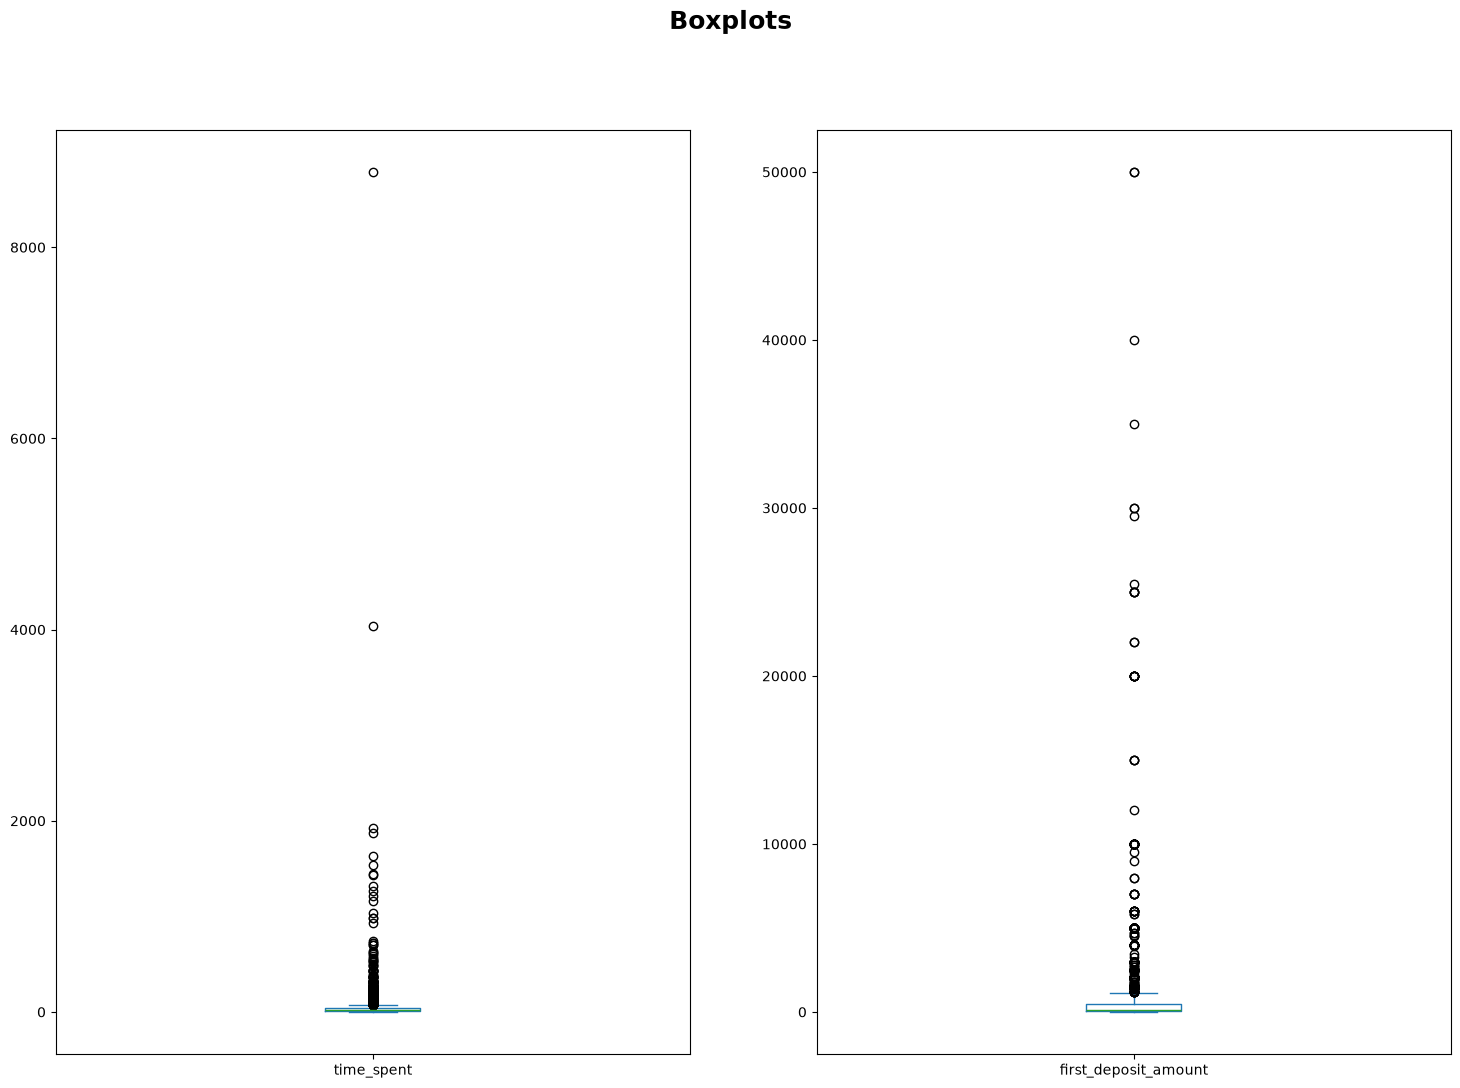

In [105]:
features_df.plot(kind="box", subplots=True, figsize=(18, 12), layout=(1, 2))
plt.suptitle("Boxplots", fontsize=18, fontweight="bold")
plt.show()

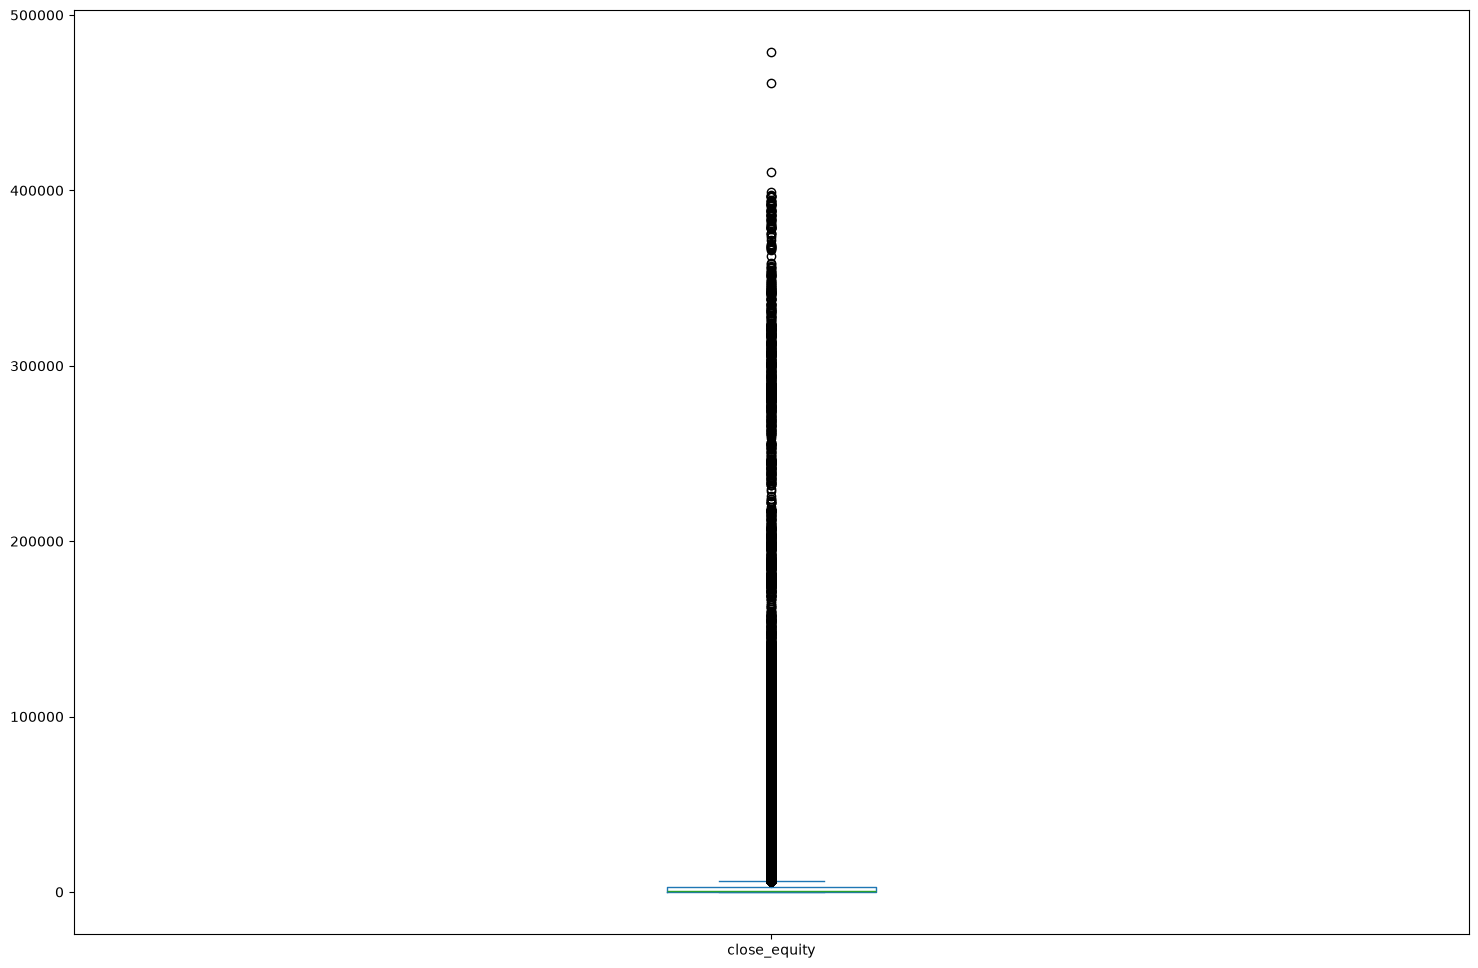

In [106]:
equity_df.plot(kind="box", figsize=(18, 12))
plt.show()

### Time Spent

In [107]:
features_df.query("time_spent > 1800").T

,1294,1306,1790,1919
risk_tolerance,high_risk_tolerance,high_risk_tolerance,med_risk_tolerance,high_risk_tolerance
investment_experience,limited_investment_exp,good_investment_exp,limited_investment_exp,no_investment_exp
liquidity_needs,very_important_liq_need,very_important_liq_need,somewhat_important_liq_need,very_important_liq_need
platform,Android,iOS,iOS,iOS
time_spent,1877.4324,8788.32945,4033.853417,1922.825117
instrument_type_first_traded,stock,stock,stock,stock
first_deposit_amount,153.75,200.0,30.0,25.0
time_horizon,short_time_horizon,long_time_horizon,short_time_horizon,short_time_horizon
user_id,14bd9c4df177b95f9589d5b3d801c5ea,17d637f5abaabd25935ed513ca64e686,37c4c0e2dd8a7a5f2d61306b6dbdb258,f004ae3c7b47bf9f170969f7ef5f768a


index 1306: contradictory very important liquidity needs with long time horizon

index 1790: short time horizon should equate to high risk tolerance

In [108]:
features_df = features_df.query("time_spent < 4000")

### First Deposit Amount

In [109]:
fda_outliers = features_df.query("first_deposit_amount > 11000")

fda_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
time_spent,26.0,35.258550,43.213843,2.498367,11.303725,21.559192,33.441792,163.017967
first_deposit_amount,26.0,25038.461538,9659.112875,12000.000000,20000.000000,22000.000000,28500.000000,50000.000000


In [110]:
print_cc(fda_outliers, cat_cols)

Total Rows: 26

'risk_tolerance': 3 [15 'high_risk_tolerance', 7 'med_risk_tolerance', 4 'low_risk_tolerance'],
'investment_experience': 4 [12 'limited_investment_exp', 10 'good_investment_exp', 3 'no_investment_exp', 1 'extensive_investment_exp'],
'liquidity_needs': 3 [21 'very_important_liq_need', 3 'not_important_liq_need', 2 'somewhat_important_liq_need'],
'platform': 3 [17 'iOS', 5 'both', 4 'Android'],
'instrument_type_first_traded': 3 [22 'stock', 2 'etp', 2 'adr'],
'time_horizon': 3 [17 'short_time_horizon', 8 'long_time_horizon', 1 'med_time_horizon'],


## 2.4 Feature Engineering

### Max Day Gap

In [111]:
# sort for gap calculation
equity_df = equity_df.sort_values(by=['user_id', 'timestamp'])

equity_df['days_diff'] = equity_df.groupby('user_id')['timestamp'].diff().dt.days

max_day_gap = equity_df.groupby('user_id')['days_diff'].max().fillna(0).rename('max_day_gap')

### Max Equity

In [112]:
max_equity = equity_df.groupby('user_id')['close_equity'].max().rename('max_equity')

### Money Flow

In [113]:
# day to day equity change
equity_df['equity_diff'] = equity_df.groupby('user_id')['close_equity'].diff()

money_flow = equity_df.groupby('user_id')['equity_diff'].mean().fillna(0).rename('money_flow')

### Churn

In [114]:
end_date = pd.to_datetime('2017-08-18')

last_active_dates = equity_df.groupby('user_id')['timestamp'].max()

end_gaps = (end_date - last_active_dates.dt.tz_localize(None)).dt.days

churn_mask = (max_day_gap >= 29) | (end_gaps >= 28)

churn = churn_mask.astype(int).rename('churn')

### Merge

In [115]:
eng_features = pd.concat([
    max_day_gap, 
    max_equity, 
    money_flow, 
    churn
], axis=1).reset_index()

features_df = features_df.merge(eng_features, on='user_id', how='inner')

In [116]:
features_df['churn'].value_counts(normalize=True) * 100

churn
0    82.072427
1    17.927573
Name: proportion, dtype: float64

Based on the provided data, approximately 18% of users have churned.

In [117]:
display(features_df[['user_id', 'max_day_gap', 'max_equity', 'money_flow', 'churn']].head(3).T)

,0,1,2
user_id,895044c23edc821881e87da749c01034,458b1d95441ced242949deefe8e4b638,c7936f653d293479e034865db9bb932f
max_day_gap,4.0,4.0,4.0
max_equity,88.9,394.92,49.24
money_flow,0.225397,0.239761,0.0
churn,0,0,0


### Clueless Trader

In [118]:
features_df.query("investment_experience == 'no_investment_exp' and instrument_type_first_traded not in ['stock', 'etp', 'reit', 'adr']").shape

(26, 13)

### NA Check

In [119]:
features_df.isnull().sum()

risk_tolerance                  0
investment_experience           0
liquidity_needs                 0
platform                        0
time_spent                      0
instrument_type_first_traded    0
first_deposit_amount            0
time_horizon                    0
user_id                         0
max_day_gap                     0
max_equity                      0
money_flow                      0
churn                           0
dtype: int64

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Exploratory Data Analysis (EDA)</p>

<a id="3"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 3.1 Data Visualization
The data is visualized to identify trends, patterns, or anomalies. This is done by looking at the feature distributions and the relationship between features, including the relationship between the features and the target variable Churn.

In [120]:
# re-do cat_cols and num_cols to include new engineered features
cat_cols = features_df.select_dtypes(include="str").columns.tolist()
cat_cols.remove("user_id")

num_cols = features_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove("churn")

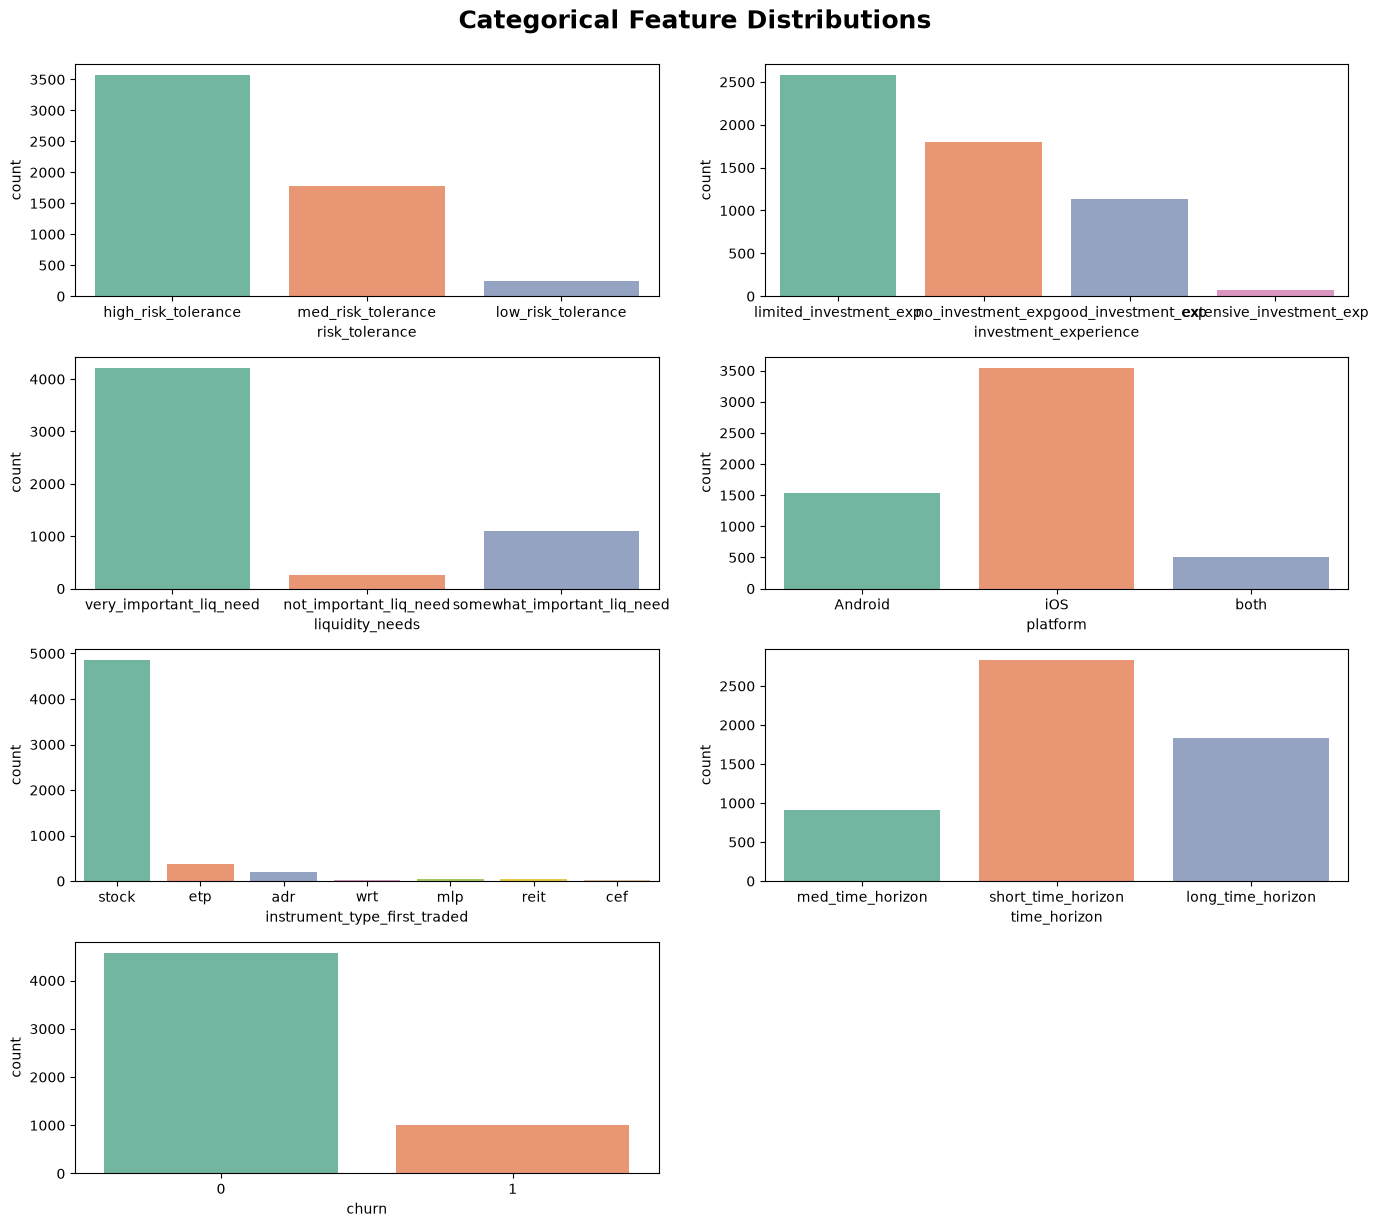

In [121]:
plt.figure(figsize=(14, len(cat_cols) * 3))
for idx, feature in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 2, idx)
    sns.countplot(x=features_df[feature], palette="Set2")

# add churn
plt.subplot(len(cat_cols), 2, len(cat_cols) + 1)
sns.countplot(x=features_df['churn'], palette="Set2")

plt.suptitle("Categorical Feature Distributions", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

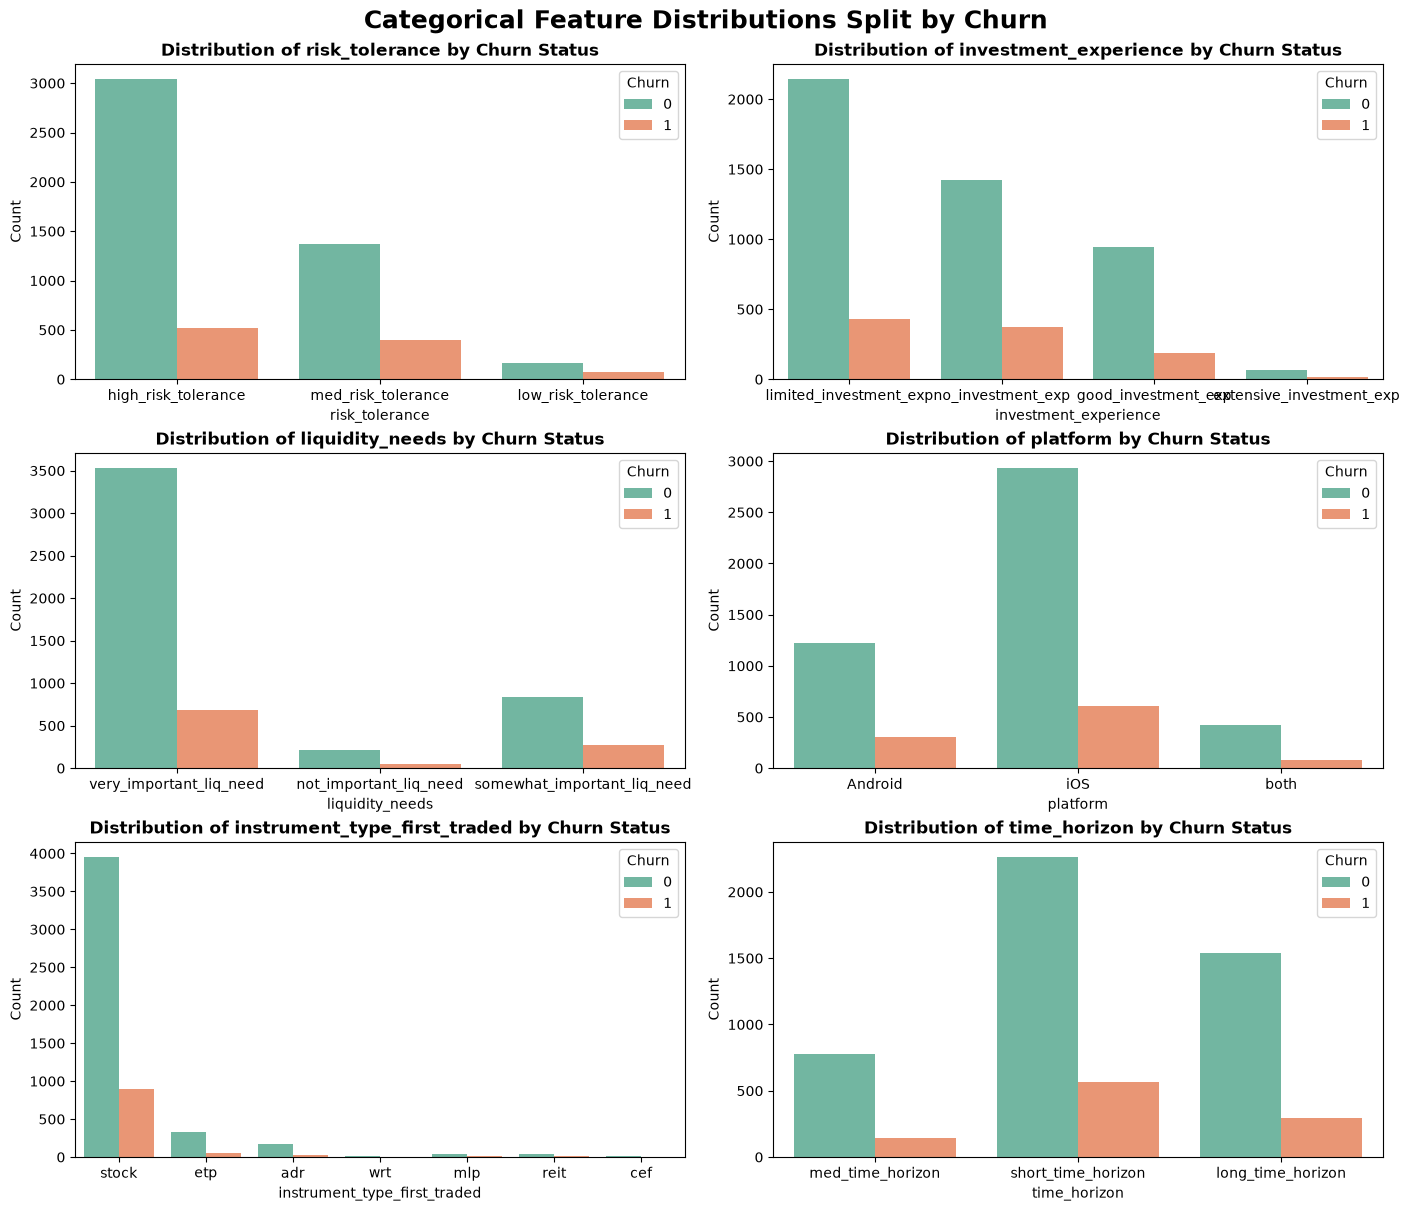

In [122]:
num_rows = (len(cat_cols) + 1) // 2

plt.figure(figsize=(14, num_rows * 4), constrained_layout=True)

for idx, feature in enumerate(cat_cols, 1):
    plt.subplot(num_rows, 2, idx)
    sns.countplot(x=features_df[feature], hue=features_df['churn'], palette="Set2")
    
    plt.title(f"Distribution of {feature} by Churn Status", fontsize=12, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend(title="Churn", loc="best")

plt.suptitle("Categorical Feature Distributions Split by Churn", fontsize=18, fontweight="bold")
plt.show()

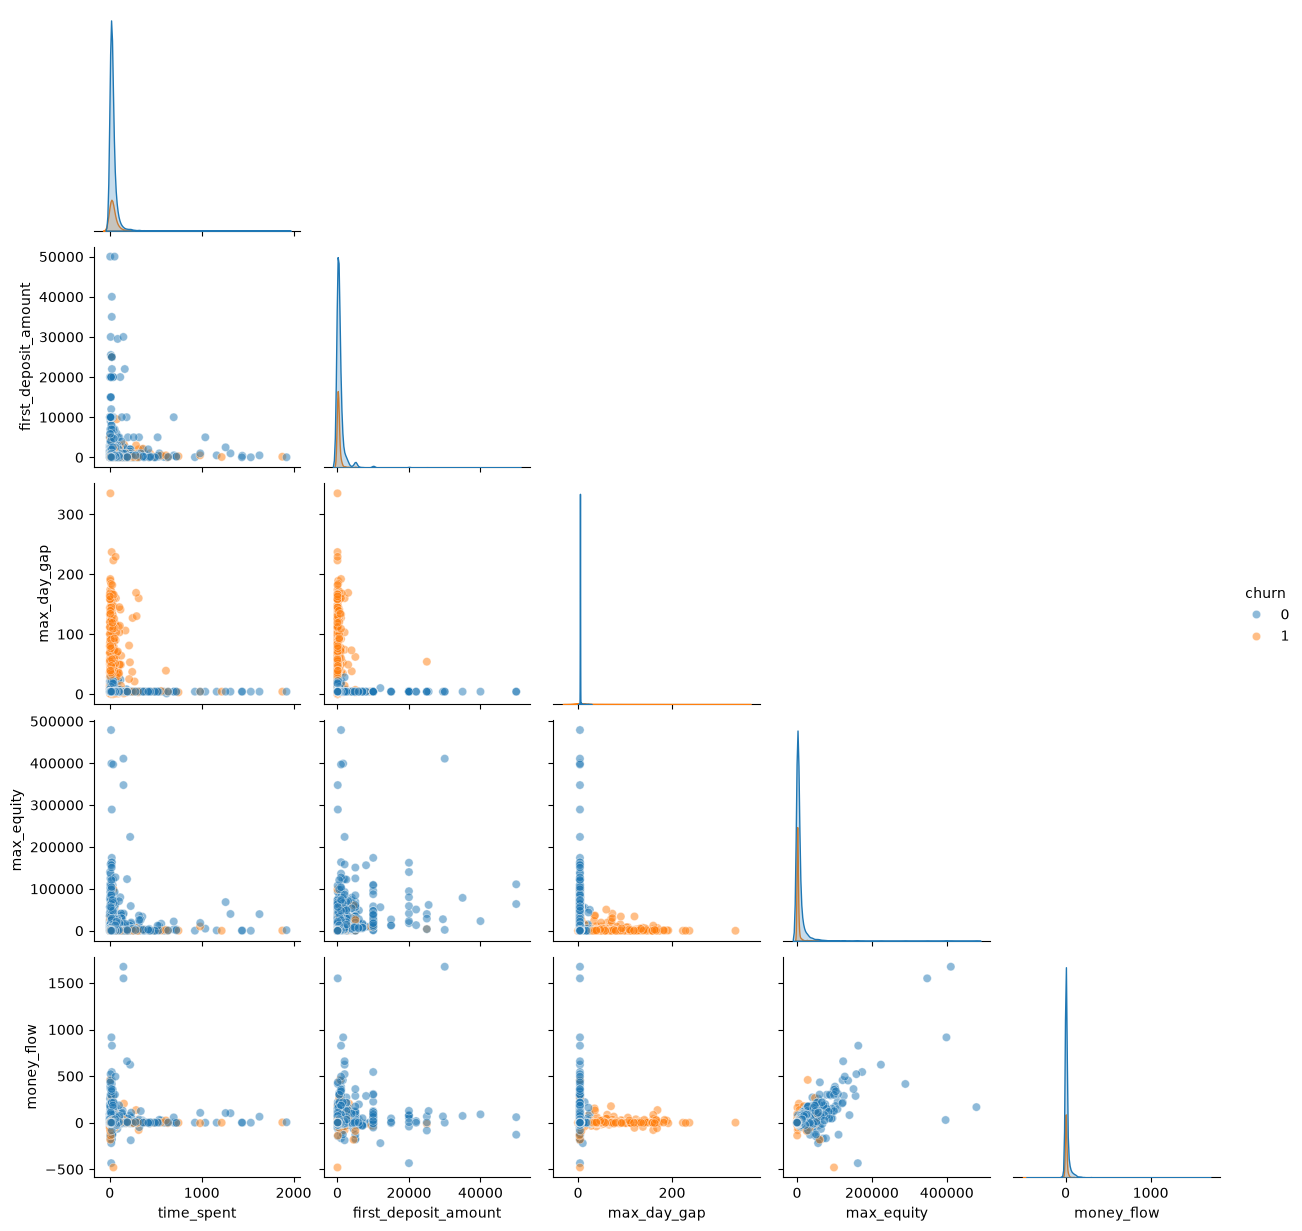

In [123]:
sns.pairplot(features_df[num_cols + ['churn']], hue='churn', diag_kind='kde', corner=True, plot_kws={'alpha': 0.5})
plt.show()

## 3.2 Correlation Analysis
Correlations between numerical features

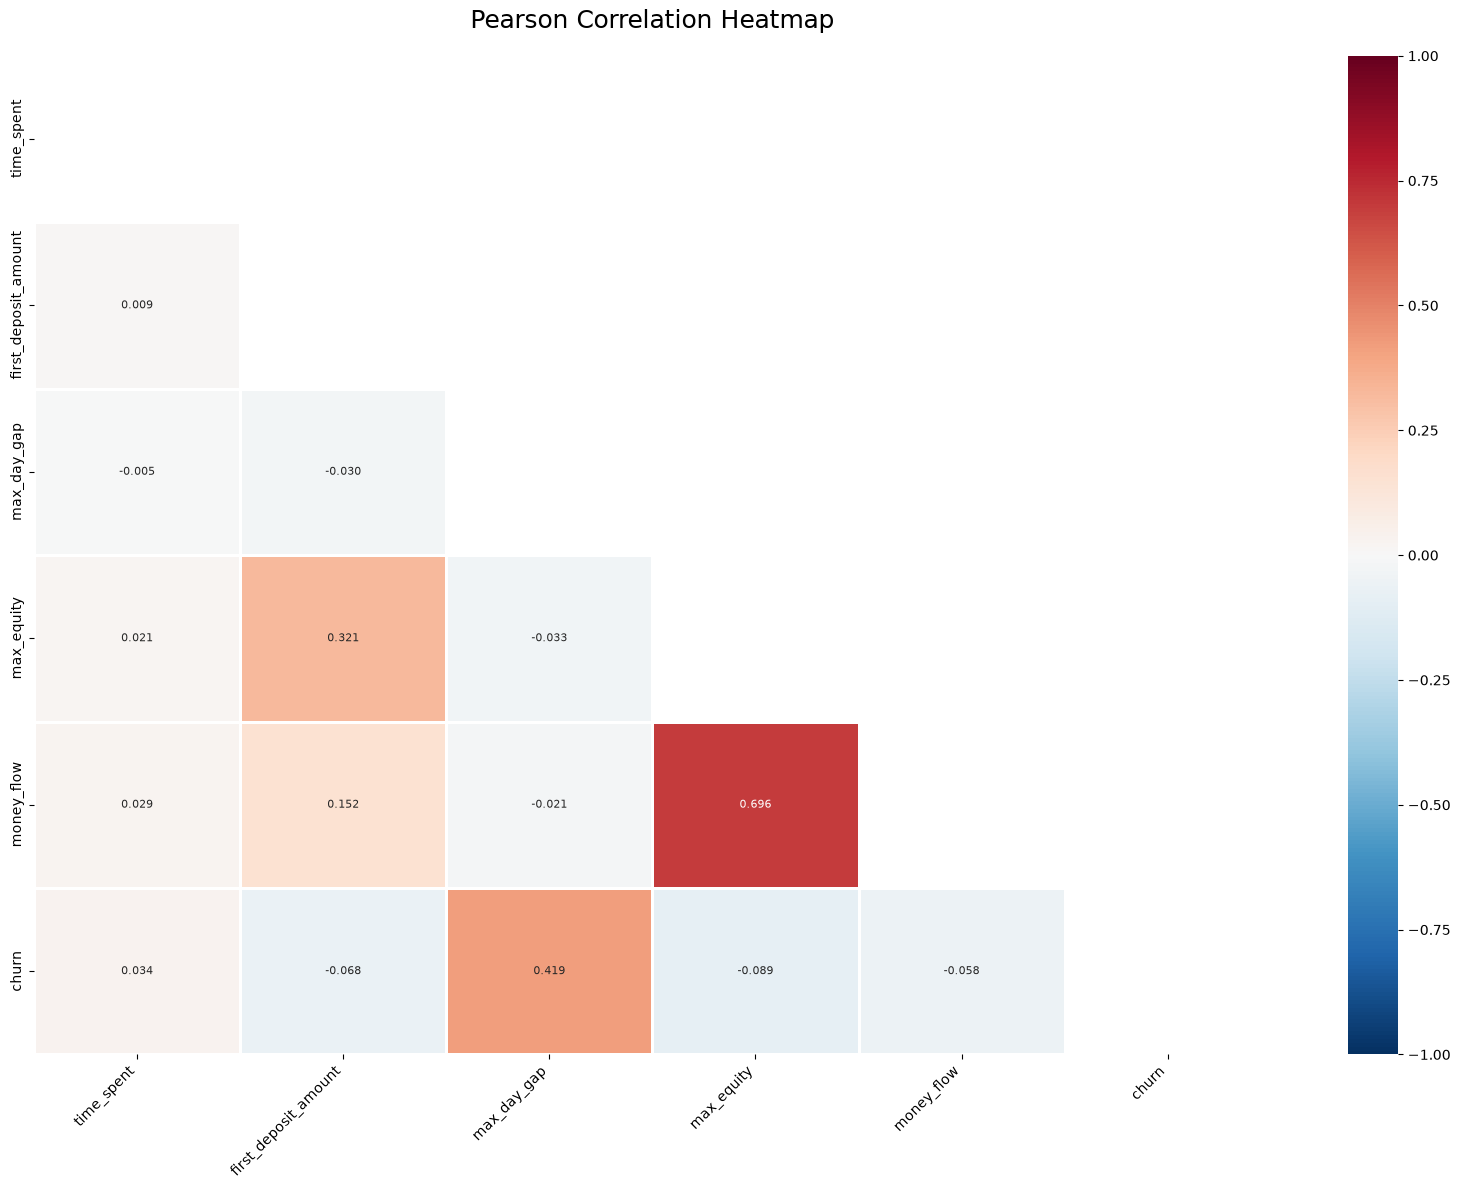

In [124]:
corr_matrix = features_df.select_dtypes(include=['int64', 'float64']).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            fmt='.3f',
            annot_kws={'size': 8},
            linewidths=1,
            linecolor='white')

plt.title('Pearson Correlation Heatmap', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">4. Scaling, Categorical Variables, and Splitting</p>

<a id="4"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>


## 4.1 Encoding Categorical Variables
ML algorithms require that input features are numbers, in order to handle categorical features:

- **Label Encoding:** For ordinal variables.
- **One-Hot Encoding:** For nominal variables.

We will use One-Hot Encoding as order is not important.

In [125]:
df = pd.get_dummies(data=features_df, columns=cat_cols, drop_first=True, dtype="int64")

df.shape

(5578, 24)

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5578 entries, 0 to 5577
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   time_spent                                    5578 non-null   float64
 1   first_deposit_amount                          5578 non-null   float64
 2   user_id                                       5578 non-null   str    
 3   max_day_gap                                   5578 non-null   float64
 4   max_equity                                    5578 non-null   float64
 5   money_flow                                    5578 non-null   float64
 6   churn                                         5578 non-null   int64  
 7   risk_tolerance_low_risk_tolerance             5578 non-null   int64  
 8   risk_tolerance_med_risk_tolerance             5578 non-null   int64  
 9   investment_experience_good_investment_exp     5578 non-null   int64  
 10 

## 4.2 Splitting
The data is split into training and testing sets:

- **Train/Test Split:** Usually a 70/30 or 80/20 split.
- **Stratified Sampling:** Used if the dataset is imbalanced, as is the case with our target variable churn.

In [127]:
X = df.drop(columns=["churn", "user_id"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">5. Models</p>

<a id="5"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 5.1 Creating Models and Fine-Tuning
Build and evaluate baseline models using different machine learning algorithms to get a benchmark for more complex models after hyperparameter tuning. Models will be compared using the ROC-AUC.

The ROC-AUC is chosen as the primary metric because the dataset is imbalanced (~18% churned), making standard accuracy misleading.

### 5.1.1 Baseline Models

In [128]:
baseline_models = {
    'LogRegression': LogisticRegression(
        random_state=SEED, 
        class_weight='balanced'
    ),
    'RandForest': RandomForestClassifier(
        random_state=SEED, 
        class_weight='balanced'
    ),
    'GradBoost': GradientBoostingClassifier(
        random_state=SEED
        # no direct class_weight support
    ),
    'AdaBoost': AdaBoostClassifier(
        random_state=SEED
        # no direct class_weight support
    ),
    'XGBoost': XGBClassifier(
        random_state=SEED, 
        eval_metric='logloss',
        scale_pos_weight=...  
        # handled separately later
    ),
    'LightGBM': LGBMClassifier(
        random_state=SEED, 
        verbose=-1,
        class_weight='balanced'
    ),
    'CatBoost': CatBoostClassifier(
        random_state=SEED, 
        silent=True, 
        allow_writing_files=False,
        auto_class_weights='Balanced'
    )
}

results = []

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# training Loop
for name, model in baseline_models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    fit_params = {}
    
    # handle model specific parameters
    if name == 'XGBoost':
        pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
        pipeline.set_params(model__scale_pos_weight=pos_weight)
        
    elif name in ['GradBoost', 'AdaBoost']:
        fit_params = {'model__sample_weight': sample_weights}
    
    # fit on the entire training set
    pipeline.fit(X_train, y_train, **fit_params)
    
    # log and evaluate
    results_df = log_and_update_results(
        model_name=name,
        fitted_pipeline=pipeline,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        results=results
    )
    
    clear_output(wait=True)
    display(results_df)

,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
0,CatBoost,1,22,0.979503,0.832478,"{'silent': True, 'auto_class_weights': 'Balanc..."
1,RandForest,1,22,1.000000,0.831998,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
2,GradBoost,1,22,0.910193,0.825674,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ..."
3,LightGBM,1,22,0.993829,0.811348,"{'boosting_type': 'gbdt', 'class_weight': 'bal..."
4,XGBoost,1,22,0.999441,0.793608,"{'objective': 'binary:logistic', 'base_score':..."
5,AdaBoost,1,22,0.781743,0.791580,"{'estimator': None, 'learning_rate': 1.0, 'n_e..."
6,LogRegression,1,22,0.758906,0.777724,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."


## 5.2 Model Comparisons
Compare the performance of different models after hyperparameter tuning.

### Gradient Boosting

In [129]:
# Setup the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('GradBoost', GradientBoostingClassifier(random_state=SEED))
])

# Set sample weights for the fit process
fit_params = {'GradBoost__sample_weight': sample_weights}

# Define the parameter grid
param_grid = {
    'GradBoost__n_estimators': randint(50, 300),
    'GradBoost__learning_rate': uniform(0.01, 0.29),
    'GradBoost__max_depth': randint(3, 12),
    'GradBoost__min_samples_split': randint(2, 20),
    'GradBoost__min_samples_leaf': randint(1, 10),
    'GradBoost__subsample': uniform(0.5, 0.5)
}

# Run the tuning function
GradBoost = tune_hyperparameters(
    pipeline=pipeline, 
    param_grid=param_grid, 
    X_train=X_train, 
    y_train=y_train, 
    fit_params=fit_params,
    seed=SEED
)

# Print the best parameters found
print_bh(GradBoost.best_params_)

# Log the results using the best estimator
model_name = list(GradBoost.best_estimator_.named_steps.keys())[-1]

results_df = log_and_update_results(
    model_name=model_name,
    fitted_pipeline=GradBoost.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results=results,
    params=GradBoost.best_params_
)

# Display the results
display(results_df[results_df['model'] == model_name])

Fitting 10 folds for each of 50 candidates, totalling 500 fits

=== Best Hyperparameters Found ===
 - learning_rate: 0.0908
 - max_depth: 3
 - min_samples_leaf: 1
 - min_samples_split: 3
 - n_estimators: 102
 - subsample: 0.7447



,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
2,GradBoost,2,22,0.910408,0.831627,"{'learning_rate': 0.09080747462861731, 'max_de..."
3,GradBoost,1,22,0.910193,0.825674,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ..."


### CatBoost

In [130]:
# Setup the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('CatBoost', CatBoostClassifier(
        random_state=SEED, 
        silent=True, 
        allow_writing_files=False,
        auto_class_weights='Balanced'
    ))
])

# Weights for CatBoost are handled internally, so no need to set sample weights

# Define the parameter grid
param_grid = {
    'CatBoost__iterations': randint(50, 400),
    'CatBoost__learning_rate': uniform(0.01, 0.29),
    'CatBoost__depth': randint(3, 12),
    'CatBoost__l2_leaf_reg': uniform(1, 10),
    'CatBoost__random_strength': uniform(0, 2),
    'CatBoost__border_count': randint(32, 255)
}

# Run the tuning function
CatBoost = tune_hyperparameters(
    pipeline=pipeline, 
    param_grid=param_grid, 
    X_train=X_train, 
    y_train=y_train, 
    #fit_params=fit_params,
    seed=SEED
)

# Print the best parameters found
print_bh(CatBoost.best_params_)

# Log the results using the best estimator
model_name = list(CatBoost.best_estimator_.named_steps.keys())[-1]

results_df = log_and_update_results(
    model_name=model_name,
    fitted_pipeline=CatBoost.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results=results,
    params=CatBoost.best_params_
)

# Display the results
display(results_df[results_df['model'] == model_name])

Fitting 10 folds for each of 50 candidates, totalling 500 fits

=== Best Hyperparameters Found ===
 - border_count: 175
 - depth: 3
 - iterations: 250
 - l2_leaf_reg: 4.2078
 - learning_rate: 0.0641
 - random_strength: 0.0816



,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
0,CatBoost,2,22,0.905067,0.843938,"{'border_count': 175, 'depth': 3, 'iterations'..."
1,CatBoost,1,22,0.979503,0.832478,"{'silent': True, 'auto_class_weights': 'Balanc..."


### LightGBM

In [131]:
# Setup the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('LightGBM', LGBMClassifier(
        random_state=SEED, 
        verbose=-1,
        class_weight='balanced'
    ))
])

# Weights for LightGBM are handled internally, so no need to set sample weights

# Define the parameter grid
param_grid = {
    'LightGBM__n_estimators': randint(50, 400),
    'LightGBM__learning_rate': uniform(0.01, 0.29),
    'LightGBM__num_leaves': randint(20, 150),
    'LightGBM__max_depth': randint(-1, 15),
    'LightGBM__min_child_samples': randint(10, 100), 
    'LightGBM__subsample': uniform(0.5, 0.5),
    'LightGBM__colsample_bytree': uniform(0.5, 0.5),
    'LightGBM__reg_alpha': uniform(0, 10),
    'LightGBM__reg_lambda': uniform(0, 10)
}

# Run the tuning function
LightGBM = tune_hyperparameters(
    pipeline=pipeline, 
    param_grid=param_grid, 
    X_train=X_train, 
    y_train=y_train, 
    #fit_params=fit_params,
    seed=SEED
)

# Print the best parameters found
print_bh(LightGBM.best_params_)

# Log the results using the best estimator
model_name = list(LightGBM.best_estimator_.named_steps.keys())[-1]

results_df = log_and_update_results(
    model_name=model_name,
    fitted_pipeline=LightGBM.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results=results,
    params=LightGBM.best_params_
)

# Display the results
display(results_df[results_df['model'] == model_name])

Fitting 10 folds for each of 50 candidates, totalling 500 fits

=== Best Hyperparameters Found ===
 - colsample_bytree: 0.5909
 - learning_rate: 0.0632
 - max_depth: 10
 - min_child_samples: 67
 - n_estimators: 71
 - num_leaves: 108
 - reg_alpha: 2.9123
 - reg_lambda: 6.1185
 - subsample: 0.5697



,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
1,LightGBM,2,22,0.921350,0.834170,"{'colsample_bytree': 0.5909124836035503, 'lear..."
6,LightGBM,1,22,0.993829,0.811348,"{'boosting_type': 'gbdt', 'class_weight': 'bal..."


### RandForest

In [132]:
# Setup the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('RandForest', RandomForestClassifier(
        random_state=SEED, 
        class_weight='balanced'
    ))
])

# Weights for RandForest are handled internally, so no need to set sample weights

# Define the parameter grid
param_grid = {
    "RandForest__max_depth": range(2, 15),
    "RandForest__n_estimators": range(10, 50),
    "RandForest__min_samples_split": [2, 3, 4],
    "RandForest__max_features": ["sqrt", "log", None,  "auto"],
    "RandForest__criterion": ["gini", "entropy"]
}

# Run the tuning function
RandForest = tune_hyperparameters(
    pipeline=pipeline, 
    param_grid=param_grid, 
    X_train=X_train, 
    y_train=y_train, 
    #fit_params=fit_params,
    seed=SEED
)

# Print the best parameters found
print_bh(RandForest.best_params_)

# Log the results using the best estimator
model_name = list(RandForest.best_estimator_.named_steps.keys())[-1]

results_df = log_and_update_results(
    model_name=model_name,
    fitted_pipeline=RandForest.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    results=results,
    params=RandForest.best_params_
)

# Display the results
display(results_df[results_df['model'] == model_name])

Fitting 10 folds for each of 50 candidates, totalling 500 fits

=== Best Hyperparameters Found ===
 - n_estimators: 28
 - min_samples_split: 4
 - max_features: None
 - max_depth: 11
 - criterion: gini



,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
3,RandForest,1,22,1.000000,0.831998,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
6,RandForest,2,22,0.977746,0.823332,"{'n_estimators': 28, 'min_samples_split': 4, '..."


## 5.3 Model Results
Best-performing model based after fine-tuning.

In [133]:
results_df

,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
0,CatBoost,2,22,0.905067,0.843938,"{'border_count': 175, 'depth': 3, 'iterations'..."
1,LightGBM,2,22,0.921350,0.834170,"{'colsample_bytree': 0.5909124836035503, 'lear..."
2,CatBoost,1,22,0.979503,0.832478,"{'silent': True, 'auto_class_weights': 'Balanc..."
3,RandForest,1,22,1.000000,0.831998,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
4,GradBoost,2,22,0.910408,0.831627,"{'learning_rate': 0.09080747462861731, 'max_de..."
5,GradBoost,1,22,0.910193,0.825674,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ..."
6,RandForest,2,22,0.977746,0.823332,"{'n_estimators': 28, 'min_samples_split': 4, '..."
7,LightGBM,1,22,0.993829,0.811348,"{'boosting_type': 'gbdt', 'class_weight': 'bal..."
8,XGBoost,1,22,0.999441,0.793608,"{'objective': 'binary:logistic', 'base_score':..."
9,AdaBoost,1,22,0.781743,0.791580,"{'estimator': None, 'learning_rate': 1.0, 'n_e..."


The best performing model is CatBoost with a test ROC-AUC of 0.843938.

## 5.4 Feature Importance
Analyze and explain the most important features:

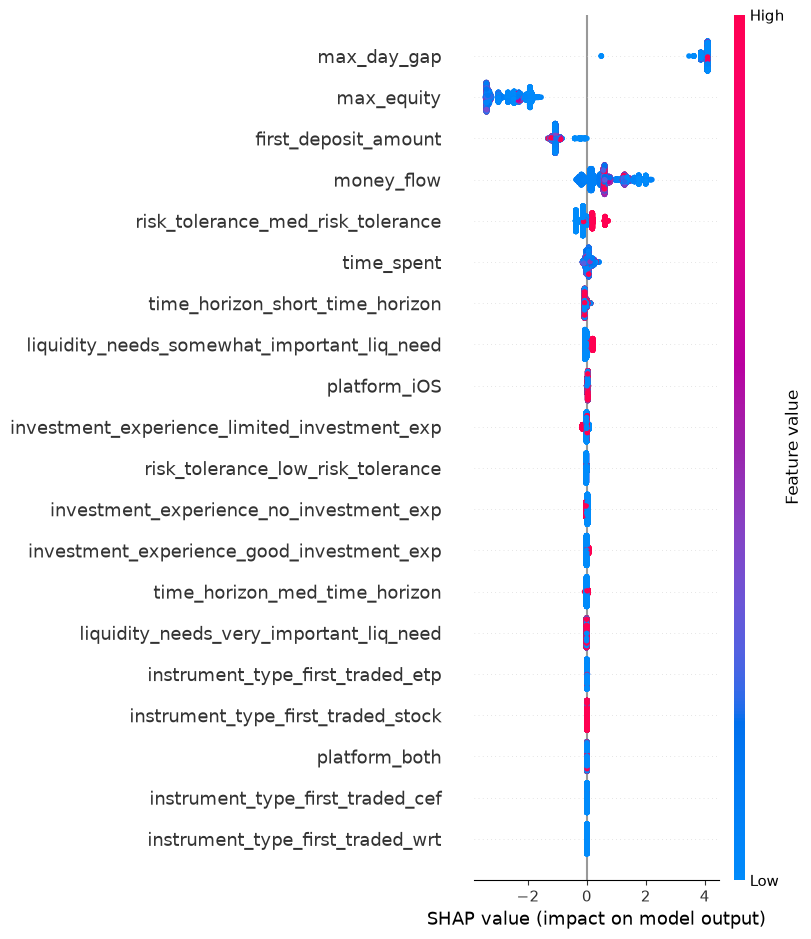

In [136]:
model = CatBoost.best_estimator_.named_steps['CatBoost'] 

# Initialize the tree explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# This creates a summary plot showing positive/negative impact
shap.summary_plot(shap_values, X_train)

Top Features:

* max_day_gap: Any gap between 2016-08-16 and 2017-08-18 despite returning to Robinhood, will likely result in user churning.

* max_equity: A user account with a larger equity value will decrease user churn.

* first_deposit_amount: A larger first deposit decreases user churn.

## 5.5 Model with Reduced Features

In [141]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': mean_abs_shap
})

feature_importance_sorted = feature_importance.sort_values(by='shap_importance', ascending=False)

### CatBoost

In [145]:
top_features = feature_importance_sorted['feature'].head(6).tolist()

X_train_top_features = X_train[top_features]
X_test_top_features = X_test[top_features]

# Setup the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('CatBoost', CatBoostClassifier(
        random_state=SEED, 
        silent=True, 
        allow_writing_files=False,
        auto_class_weights='Balanced'
    ))
])

# Weights for CatBoost are handled internally, so no need to set sample weights

# Define the parameter grid
param_grid = {
    'CatBoost__iterations': randint(50, 400),
    'CatBoost__learning_rate': uniform(0.01, 0.29),
    'CatBoost__depth': randint(3, 12),
    'CatBoost__l2_leaf_reg': uniform(1, 10),
    'CatBoost__random_strength': uniform(0, 2),
    'CatBoost__border_count': randint(32, 255)
}

# Run the tuning function
CatBoost = tune_hyperparameters(
    pipeline=pipeline, 
    param_grid=param_grid, 
    X_train=X_train_top_features, 
    y_train=y_train, 
    #fit_params=fit_params,
    seed=SEED
)

# Print the best parameters found
print_bh(CatBoost.best_params_)

# Log the results using the best estimator
model_name = list(CatBoost.best_estimator_.named_steps.keys())[-1]

results_df = log_and_update_results(
    model_name=model_name,
    fitted_pipeline=CatBoost.best_estimator_,
    X_train=X_train_top_features,
    y_train=y_train,
    X_test=X_test_top_features,
    y_test=y_test,
    results=results,
    params=CatBoost.best_params_
)

# Display the results
display(results_df[results_df['model'] == model_name])

Fitting 10 folds for each of 50 candidates, totalling 500 fits

=== Best Hyperparameters Found ===
 - border_count: 247
 - depth: 5
 - iterations: 130
 - l2_leaf_reg: 8.1134
 - learning_rate: 0.2392
 - random_strength: 1.2119



,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
0,CatBoost,5,6,0.910157,0.844656,"{'border_count': 247, 'depth': 5, 'iterations'..."
1,CatBoost,7,6,0.910157,0.844656,"{'border_count': 247, 'depth': 5, 'iterations'..."
2,CatBoost,2,22,0.905067,0.843938,"{'border_count': 175, 'depth': 3, 'iterations'..."
3,CatBoost,4,5,0.900108,0.841629,"{'border_count': 224, 'depth': 5, 'iterations'..."
4,CatBoost,6,7,0.912783,0.835120,"{'border_count': 224, 'depth': 5, 'iterations'..."
6,CatBoost,1,22,0.979503,0.832478,"{'silent': True, 'auto_class_weights': 'Balanc..."
8,CatBoost,3,4,0.899126,0.831687,"{'border_count': 247, 'depth': 5, 'iterations'..."


## 5.6 Final Model

In [146]:
results_df

,model,run_id,features,train_roc_auc,test_roc_auc,hyperparameters
0,CatBoost,5,6,0.910157,0.844656,"{'border_count': 247, 'depth': 5, 'iterations'..."
1,CatBoost,7,6,0.910157,0.844656,"{'border_count': 247, 'depth': 5, 'iterations'..."
2,CatBoost,2,22,0.905067,0.843938,"{'border_count': 175, 'depth': 3, 'iterations'..."
3,CatBoost,4,5,0.900108,0.841629,"{'border_count': 224, 'depth': 5, 'iterations'..."
4,CatBoost,6,7,0.912783,0.835120,"{'border_count': 224, 'depth': 5, 'iterations'..."
5,LightGBM,2,22,0.921350,0.834170,"{'colsample_bytree': 0.5909124836035503, 'lear..."
6,CatBoost,1,22,0.979503,0.832478,"{'silent': True, 'auto_class_weights': 'Balanc..."
7,RandForest,1,22,1.000000,0.831998,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
8,CatBoost,3,4,0.899126,0.831687,"{'border_count': 247, 'depth': 5, 'iterations'..."
9,GradBoost,2,22,0.910408,0.831627,"{'learning_rate': 0.09080747462861731, 'max_de..."


The final model is CatBoost trained on the 6 most important features with a ROC AUC score of 0.844656.

## 5.7 Prediction on All User IDs

In [164]:
# features the model was trained on (top 6 features)
# df was created in the encoding step (section 4.1)
predict_df = df[top_features]

# probabilities
all_churn_probs = CatBoost.best_estimator_.predict_proba(predict_df)[:, 1]

# binary predictions
all_churn_preds = CatBoost.best_estimator_.predict(predict_df)

# prediction dataframe
churn_df = pd.DataFrame({
    'user_id': df['user_id'],
    'churn_probability': all_churn_probs,
    'predicted_churn': all_churn_preds,
    'actual_churn': df['churn']
})

# display
churn_df.head().T

,0,1,2,3,4
user_id,895044c23edc821881e87da749c01034,458b1d95441ced242949deefe8e4b638,c7936f653d293479e034865db9bb932f,b255d4bd6c9ba194d3a350b3e76c6393,4a168225e89375b8de605cbc0977ae91
churn_probability,0.487491,0.404201,0.260802,0.269587,0.31402
predicted_churn,0,0,0,0,0
actual_churn,0,0,0,0,0


### Confusion Matrix

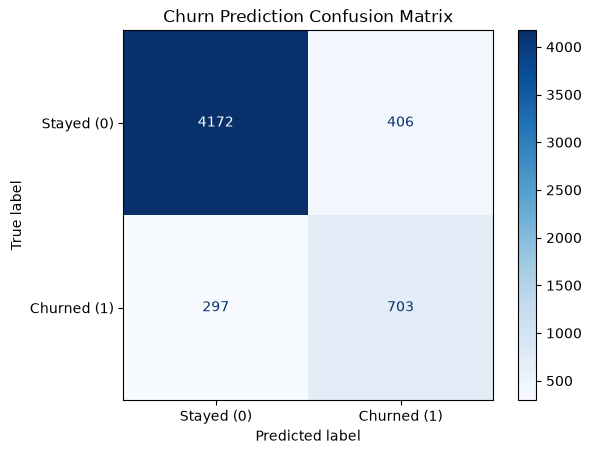

In [167]:
# true and predicted labels
y_true = churn_df['actual_churn']
y_pred = churn_df['predicted_churn']

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])

disp.plot(cmap=plt.cm.Blues)

plt.title("Churn Prediction Confusion Matrix")
plt.show()

## 5.8 Pickle the Model
Save the final model for future deployment:

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">6. Conclusion</p>

<a id="6"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## Final Remarks

### Key Takeaways

* Approximately 18% of users have churned.

* Top 6 features used to predict user churn include:
    * max_day_gap
    * max_equity
    * first_deposit_amount
    * money_flow
    * risk_tolerance_med_risk_tolerance
    * time_spent

* The best performing model was CatBoost on top 6 features with a ROC AUC score of 0.844656.

* Out of all the user ids, the CatBoost model correctly identified 703 out of the 1000 churned users

### What was learned

* Don't exceed 28 for max day gap to avoid data leakage
* For classification report precision, recall, and f1 and confusion matrix
* Possibly split train and test data by date